In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import os

# Define the device (GPU or CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define Siamese Network class (same as you had)
class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        self.cnn1 = nn.Sequential(
            nn.Conv2d(1, 96, kernel_size=11, stride=1),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(3, stride=2),

            nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(3, stride=2),
            nn.Dropout2d(p=0.3),

            nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2),
            nn.Dropout2d(p=0.3),
        )

        self.fc1 = nn.Sequential(
            nn.Linear(25600, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.5),

            nn.Linear(1024, 128),
            nn.ReLU(inplace=True),

            nn.Linear(128, 2)
        )

    def forward_once(self, x):
        output = self.cnn1(x)
        output = output.view(output.size()[0], -1)
        output = self.fc1(output)
        return output

    def forward(self, input1, input2):
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        return output1, output2

# Define the Contrastive Loss class
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=2.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        euclidean_distance = F.pairwise_distance(output1, output2, keepdim=True)
        loss_contrastive = torch.mean((1 - label) * torch.pow(euclidean_distance, 2) +
                                      (label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))
        return loss_contrastive

# Prepare the dataset (same as your existing code)
class SiameseData(Dataset):
    def __init__(self, train_csv=None, train_dir=None, transform=None):
        self.train_df = pd.read_csv(train_csv)
        self.train_df.columns = ['image1', 'image2', 'label']
        self.train_dir = train_dir
        self.transform = transform

    def __getitem__(self, index):
        image1_path = os.path.join(self.train_dir, self.train_df.iat[index, 0])
        image2_path = os.path.join(self.train_dir, self.train_df.iat[index, 1])
        img1 = Image.open(image1_path).convert("L")
        img2 = Image.open(image2_path).convert("L")

        if self.transform is not None:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, torch.tensor([int(self.train_df.iat[index, 2])], dtype=torch.float32)

    def __len__(self):
        return len(self.train_df)

# Define the training function
def train(epochs, max_lr, model, train_dl, opt_func=torch.optim.SGD):
    torch.cuda.empty_cache()
    losses = []

    optimizer = opt_func(model.parameters(), lr=max_lr)
    sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs,
                                                steps_per_epoch=len(train_dl))

    for epoch in range(1, epochs + 1):
        model.train()
        for batch_idx, (img0, img1, label) in enumerate(train_dl):
            img0, img1, label = img0.to(device), img1.to(device), label.to(device)
            optimizer.zero_grad()
            output1, output2 = model(img0, img1)
            loss_contrastive = criterion(output1, output2, label)
            loss_contrastive.backward()
            losses.append(loss_contrastive.item())
            optimizer.step()
        print(f'Cost at epoch {epoch} is {sum(losses)/len(losses)}')

    # Save the model after training
    torch.save(model.state_dict(), "siamese_model.pth")
    print("Model saved successfully!")

    return model

# Define data transformation
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor()
])

# Prepare data loaders (same as your existing code)
train_csv = "/content/drive/MyDrive/sign_data/train_data.csv"
train_dir = "/content/drive/MyDrive/sign_data/train"
train_ds = SiameseData(train_csv, train_dir, transform=transform)
train_dl = DataLoader(train_ds, shuffle=True, batch_size=32)

# Create and move the model to the device
model = SiameseNetwork().to(device)
criterion = ContrastiveLoss()

# Train the model
epochs = 5
max_lr = 0.01
opt_func = torch.optim.Adam

history = train(epochs, max_lr, model, train_dl, opt_func)


/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:1538: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


Cost at epoch 1 is 0.8543300982513375
Cost at epoch 2 is 0.670621311348496
Cost at epoch 3 is 0.5460469698784848
Cost at epoch 4 is 0.4386552214762324
Cost at epoch 5 is 0.360421450075773
Model saved successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import os

# Define the device (GPU or CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define Siamese Network class
class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        self.cnn1 = nn.Sequential(
            nn.Conv2d(1, 96, kernel_size=11, stride=1),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(3, stride=2),

            nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(3, stride=2),
            nn.Dropout2d(p=0.3),

            nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2),
            nn.Dropout2d(p=0.3),
        )

        self.fc1 = nn.Sequential(
            nn.Linear(25600, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.5),

            nn.Linear(1024, 128),
            nn.ReLU(inplace=True),

            nn.Linear(128, 2)
        )

    def forward_once(self, x):
        output = self.cnn1(x)
        output = output.view(output.size()[0], -1)
        output = self.fc1(output)
        return output

    def forward(self, input1, input2):
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        return output1, output2

# Define the Contrastive Loss class
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=2.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # Ensure label is a 1D tensor (batch_size,)
        label = label.view(-1)

        # Compute Euclidean distance
        euclidean_distance = F.pairwise_distance(output1, output2)

        # Compute contrastive loss
        loss_contrastive = torch.mean(
            (1 - label) * torch.pow(euclidean_distance, 2) +  # For similar pairs
            (label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2)  # For dissimilar pairs
        )

        return loss_contrastive

# Prepare the dataset
class SiameseData(Dataset):
    def __init__(self, train_csv=None, train_dir=None, transform=None):
        self.train_df = pd.read_csv(train_csv)
        self.train_df.columns = ['image1', 'image2', 'label']
        self.train_dir = train_dir
        self.transform = transform

    def __getitem__(self, index):
        image1_path = os.path.join(self.train_dir, self.train_df.iat[index, 0])
        image2_path = os.path.join(self.train_dir, self.train_df.iat[index, 1])
        img1 = Image.open(image1_path).convert("L")
        img2 = Image.open(image2_path).convert("L")

        if self.transform is not None:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        # Return label as a scalar tensor
        label = torch.tensor(int(self.train_df.iat[index, 2]), dtype=torch.float32)
        return img1, img2, label

    def __len__(self):
        return len(self.train_df)

# Define the training function
def train(epochs, max_lr, model, train_dl, opt_func=torch.optim.SGD):
    torch.cuda.empty_cache()
    losses = []

    optimizer = opt_func(model.parameters(), lr=max_lr)
    sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs,
                                                steps_per_epoch=len(train_dl))

    for epoch in range(1, epochs + 1):
        model.train()
        for batch_idx, (img0, img1, label) in enumerate(train_dl):
            img0, img1, label = img0.to(device), img1.to(device), label.to(device)
            optimizer.zero_grad()
            output1, output2 = model(img0, img1)
            loss_contrastive = criterion(output1, output2, label)
            loss_contrastive.backward()
            losses.append(loss_contrastive.item())
            optimizer.step()
        print(f'Cost at epoch {epoch} is {sum(losses)/len(losses)}')

    # Save the model after training
    torch.save(model.state_dict(), "siamese_model.pth")
    print("Model saved successfully!")

    return model

# Define data transformation
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor()
])

# Prepare data loaders
train_csv = "/content/drive/MyDrive/sign_data/train_data.csv"
train_dir = "/content/drive/MyDrive/sign_data/train"
train_ds = SiameseData(train_csv, train_dir, transform=transform)
train_dl = DataLoader(train_ds, shuffle=True, batch_size=32)

# Create and move the model to the device
model = SiameseNetwork().to(device)
criterion = ContrastiveLoss()

# Train the model
epochs = 10
max_lr = 0.01
opt_func = torch.optim.Adam

history = train(epochs, max_lr, model, train_dl, opt_func)

/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:1538: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


Cost at epoch 1 is 0.8344557238101302
Cost at epoch 2 is 0.681624410432807
Cost at epoch 3 is 0.5591196680870814
Cost at epoch 4 is 0.4514912912761921
Cost at epoch 5 is 0.3731216275689292
Cost at epoch 6 is 0.3194319279745503
Cost at epoch 7 is 0.28637885147680386
Cost at epoch 8 is 0.2528542689649153
Cost at epoch 9 is 0.22791015922889135
Cost at epoch 10 is 0.20570685265552316
Model saved successfully!


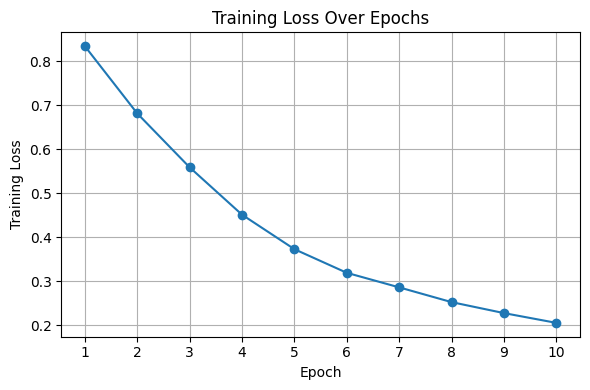

In [ ]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
loss_values = [
    0.8344557238101302,
    0.681624410432807,
    0.5591196680870814,
    0.4514912912761921,
    0.3731216275689292,
    0.3194319279745503,
    0.28637885147680386,
    0.2528542689649153,
    0.22791015922889135,
    0.20570685265552316,
]

plt.figure(figsize=(6,4))
plt.plot(epochs, loss_values, marker='o', linestyle='-')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.grid(True)
plt.xticks(epochs)  # Ensure all epochs are labeled
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, test_dl, threshold=1.0):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for img0, img1, label in test_dl:
            img0, img1, label = img0.to(device), img1.to(device), label.to(device)
            output1, output2 = model(img0, img1)
            euclidean_distance = F.pairwise_distance(output1, output2)
            predictions = (euclidean_distance > threshold).float()  # Threshold-based classification

            y_true.extend(label.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    return acc, precision, recall, f1


In [ ]:
# Performance Metrics:
# Accuracy, precision, recall, and F1-score on the test set.
# Confusion matrix data (if available).
# Average similarity scores for genuine and forged pairs.
# Any other relevant metrics you collected.

In [ ]:


# Load test dataset
test_csv = "/content/drive/MyDrive/sign_data/test_data.csv"
test_dir = "/content/drive/MyDrive/sign_data/test"
test_ds = SiameseData(test_csv, test_dir, transform=transform)
test_dl = DataLoader(test_ds, batch_size=32, shuffle=False)

# Evaluation function
def evaluate(model, test_dl, threshold=1.0):
    y_true = []
    y_pred = []

    with torch.no_grad():
        for img1, img2, label in test_dl:
            img1, img2, label = img1.to(device), img2.to(device), label.to(device)
            output1, output2 = model(img1, img2)

            # Compute Euclidean distance
            euclidean_distance = F.pairwise_distance(output1, output2)

            # Predict similar (0) if distance < threshold, otherwise dissimilar (1)
            predictions = (euclidean_distance > threshold).float()

            y_true.extend(label.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())

    # Compute evaluation metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    return accuracy, precision, recall, f1

# Run evaluation
evaluate(model, test_dl)


/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:1538: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


Accuracy: 0.9937
Precision: 1.0000
Recall: 0.9879
F1-score: 0.9939


(0.9937358621889681, 1.0, 0.9878991596638655, 0.993912749408184)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import os

# Define the device (GPU or CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define Siamese Network class
class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        self.cnn1 = nn.Sequential(
            nn.Conv2d(1, 96, kernel_size=11, stride=1),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(3, stride=2),

            nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(3, stride=2),
            nn.Dropout2d(p=0.3),

            nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2),
            nn.Dropout2d(p=0.3),
        )

        self.fc1 = nn.Sequential(
            nn.Linear(25600, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.5),

            nn.Linear(1024, 128),
            nn.ReLU(inplace=True),

            nn.Linear(128, 2)
        )

    def forward_once(self, x):
        output = self.cnn1(x)
        output = output.view(output.size()[0], -1)
        output = self.fc1(output)
        return output

    def forward(self, input1, input2):
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        return output1, output2

# Define the Contrastive Loss class
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=2.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # Ensure label is a 1D tensor (batch_size,)
        label = label.view(-1)

        # Compute Euclidean distance
        euclidean_distance = F.pairwise_distance(output1, output2)

        # Compute contrastive loss
        loss_contrastive = torch.mean(
            (1 - label) * torch.pow(euclidean_distance, 2) +  # For similar pairs
            (label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2)  # For dissimilar pairs
        )

        return loss_contrastive

# Prepare the dataset
class SiameseData(Dataset):
    def __init__(self, train_csv=None, train_dir=None, transform=None):
        self.train_df = pd.read_csv(train_csv)
        self.train_df.columns = ['image1', 'image2', 'label']
        self.train_dir = train_dir
        self.transform = transform

    def __getitem__(self, index):
        image1_path = os.path.join(self.train_dir, self.train_df.iat[index, 0])
        image2_path = os.path.join(self.train_dir, self.train_df.iat[index, 1])
        img1 = Image.open(image1_path).convert("L")
        img2 = Image.open(image2_path).convert("L")

        if self.transform is not None:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        # Return label as a scalar tensor
        label = torch.tensor(int(self.train_df.iat[index, 2]), dtype=torch.float32)
        return img1, img2, label

    def __len__(self):
        return len(self.train_df)

# Define the training function
def train(epochs, max_lr, model, train_dl, opt_func=torch.optim.SGD):
    torch.cuda.empty_cache()
    losses = []

    optimizer = opt_func(model.parameters(), lr=max_lr)
    sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs,
                                                steps_per_epoch=len(train_dl))

    for epoch in range(1, epochs + 1):
        model.train()
        for batch_idx, (img0, img1, label) in enumerate(train_dl):
            img0, img1, label = img0.to(device), img1.to(device), label.to(device)
            optimizer.zero_grad()
            output1, output2 = model(img0, img1)
            loss_contrastive = criterion(output1, output2, label)
            loss_contrastive.backward()
            losses.append(loss_contrastive.item())
            optimizer.step()
        print(f'Cost at epoch {epoch} is {sum(losses)/len(losses)}')

    # Save the model after training
    torch.save(model.state_dict(), "siamese_model.pth")
    print("Model saved successfully!")

    return model

# Define data transformation
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor()
])